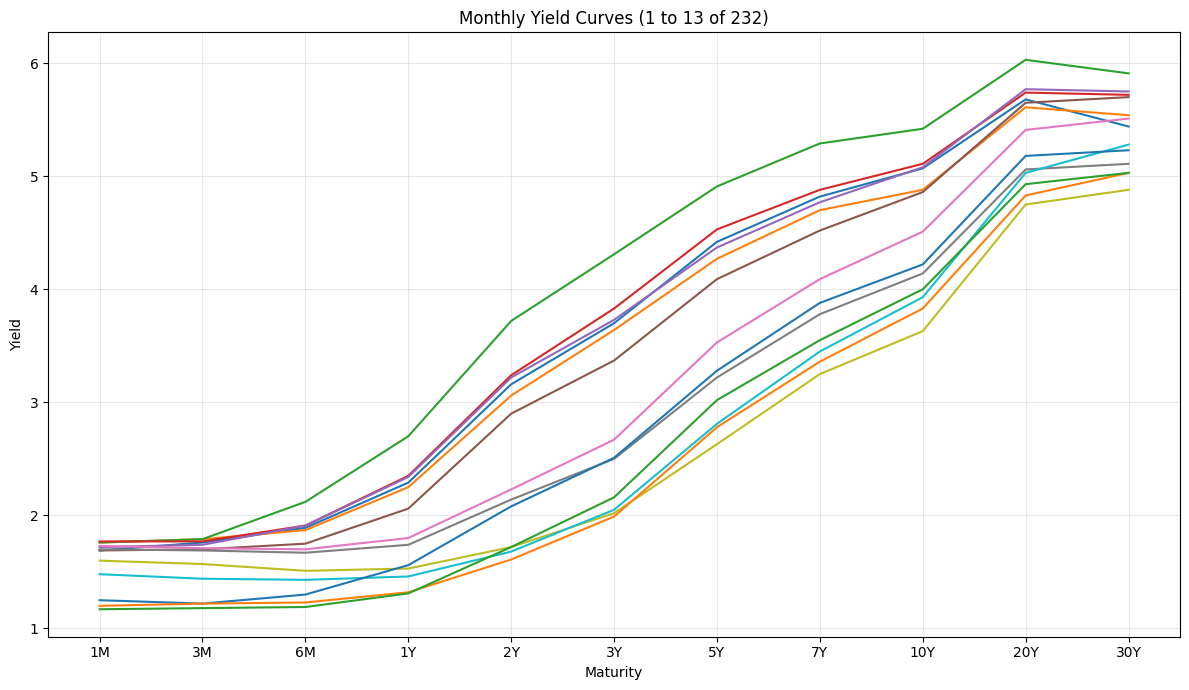

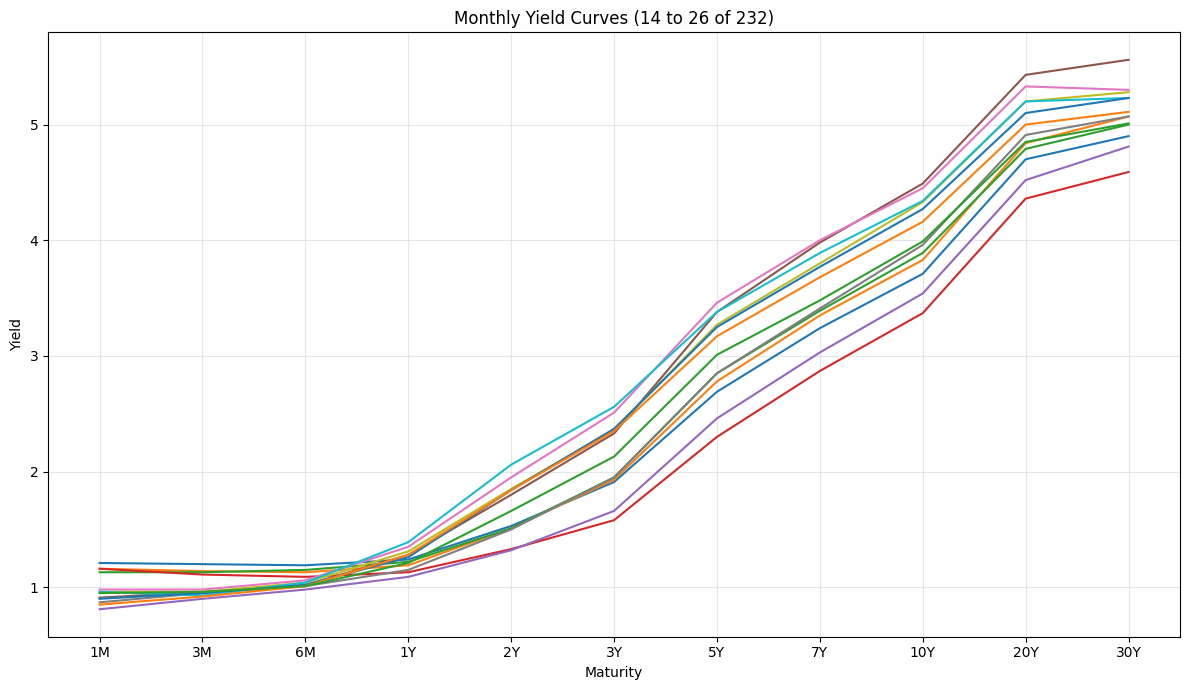

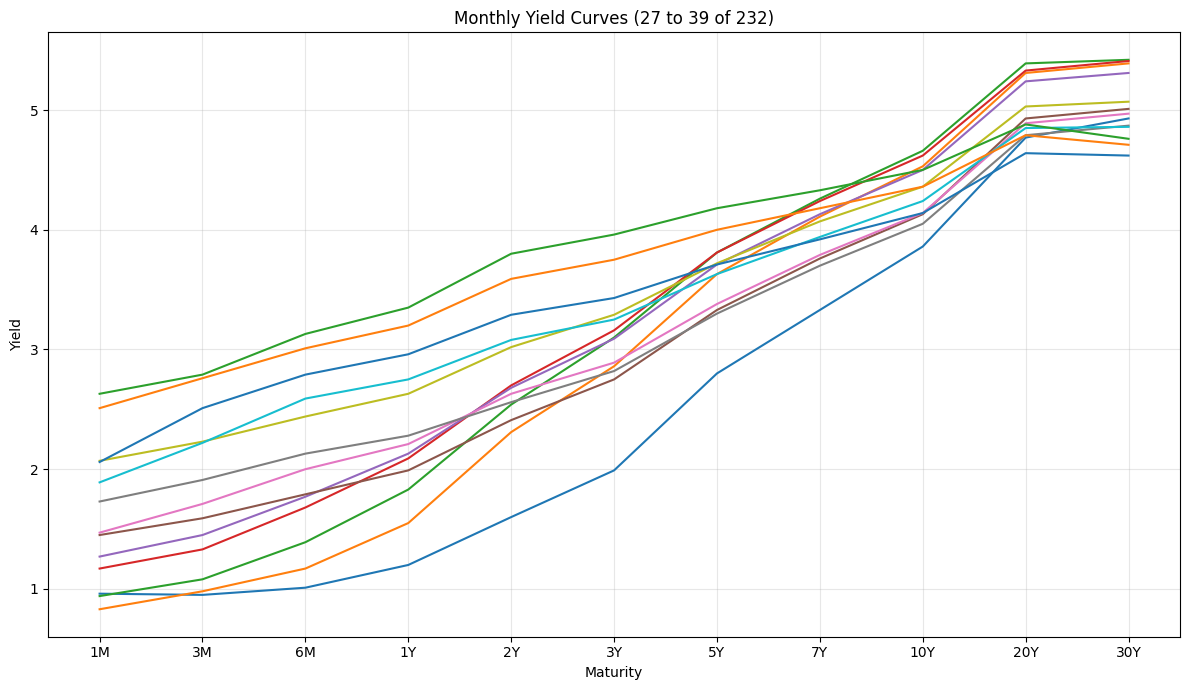

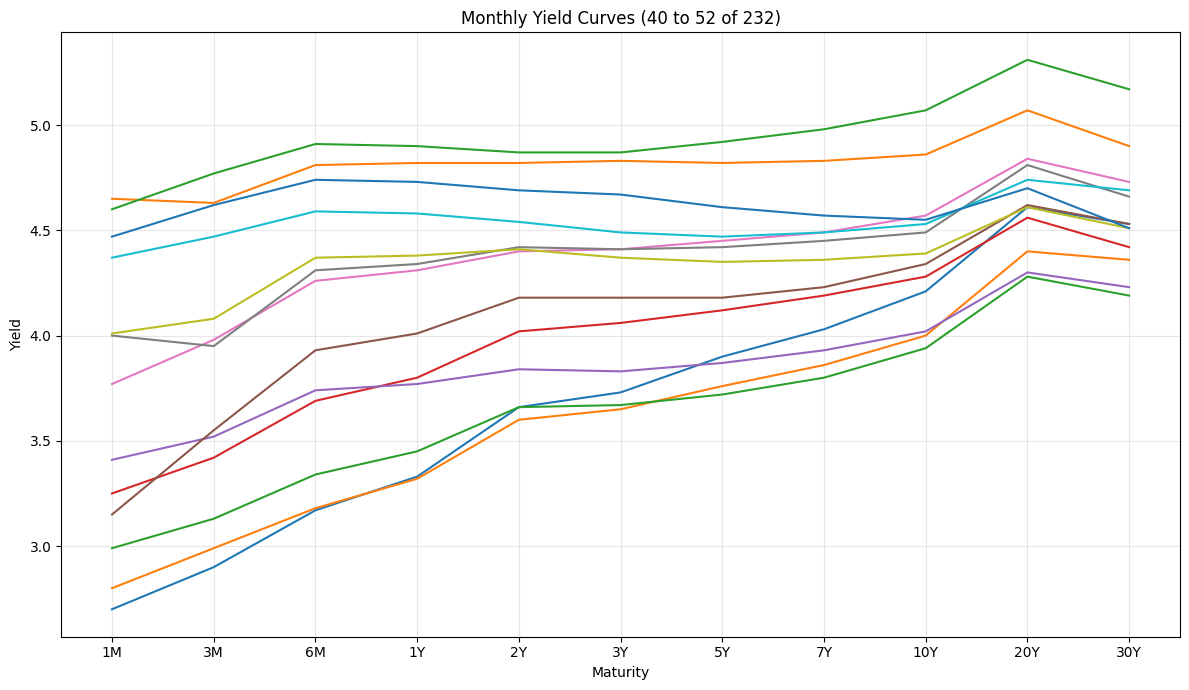

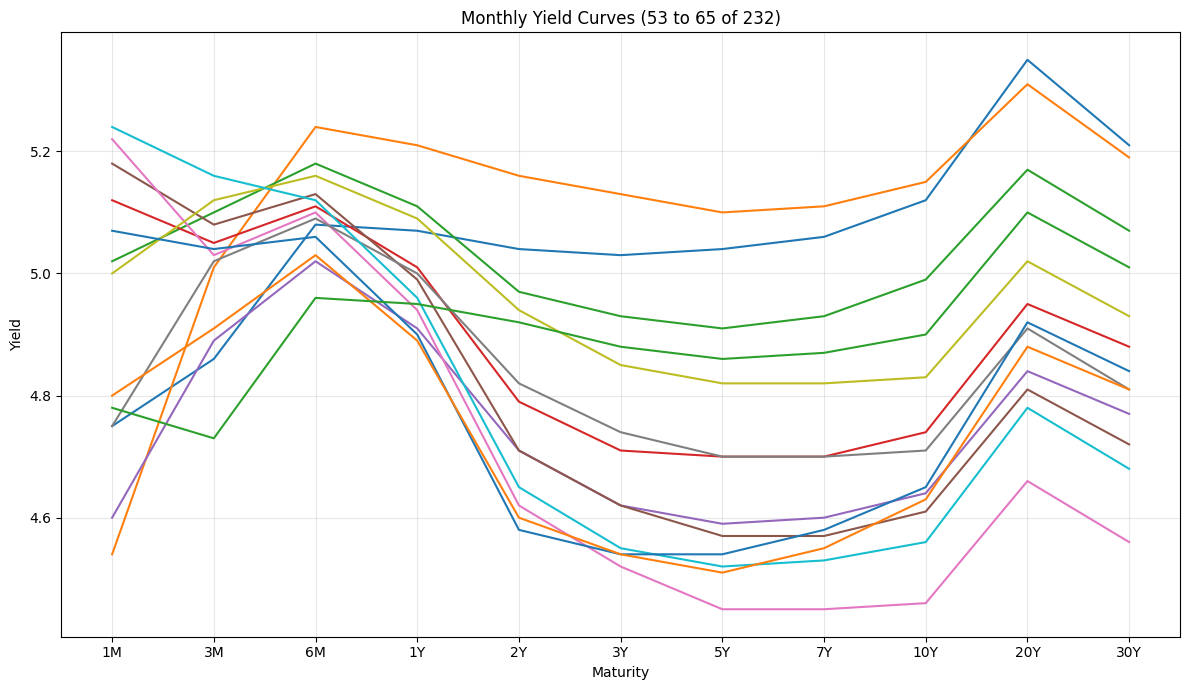

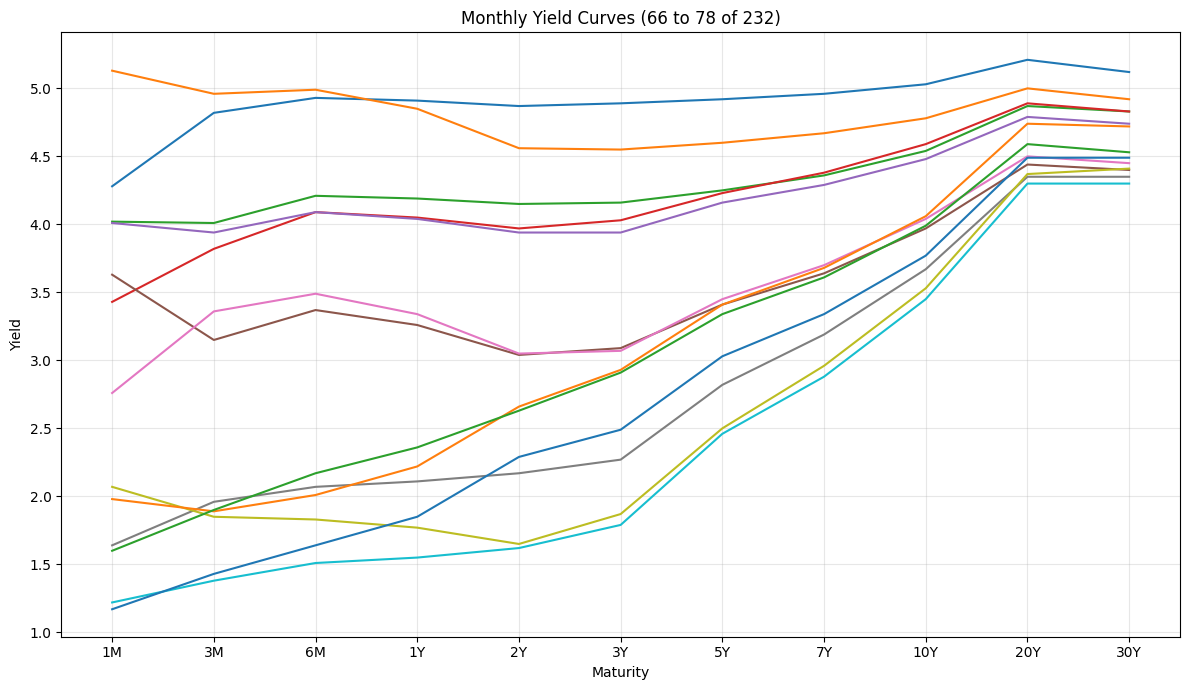

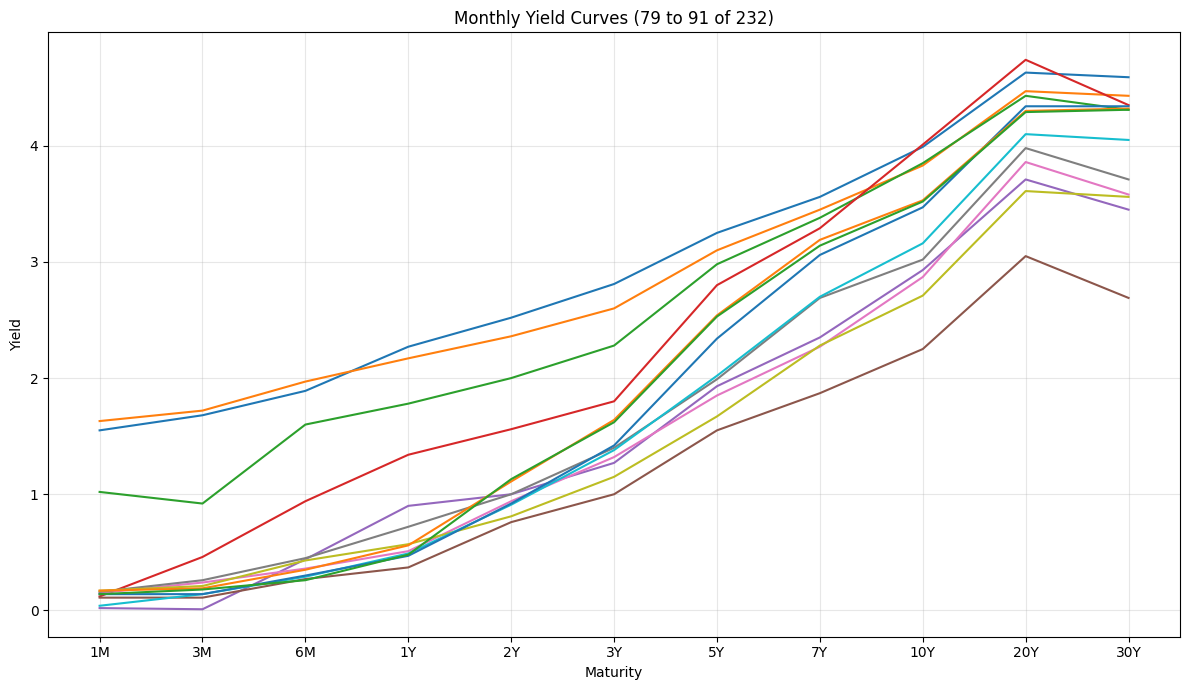

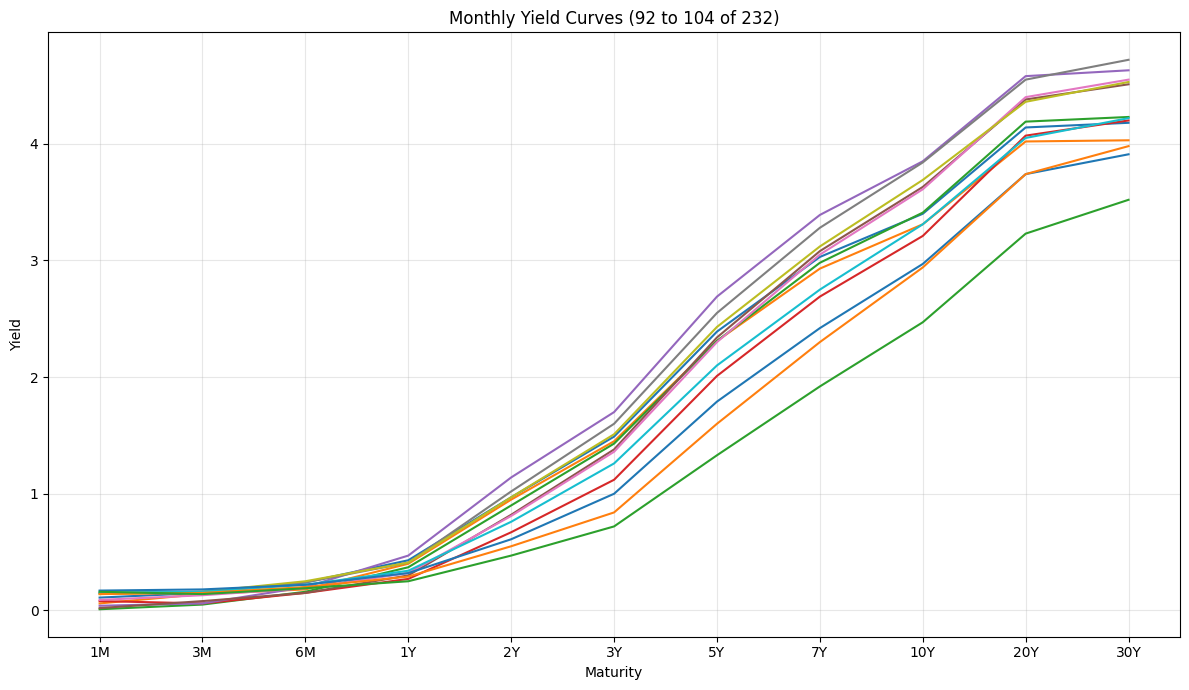

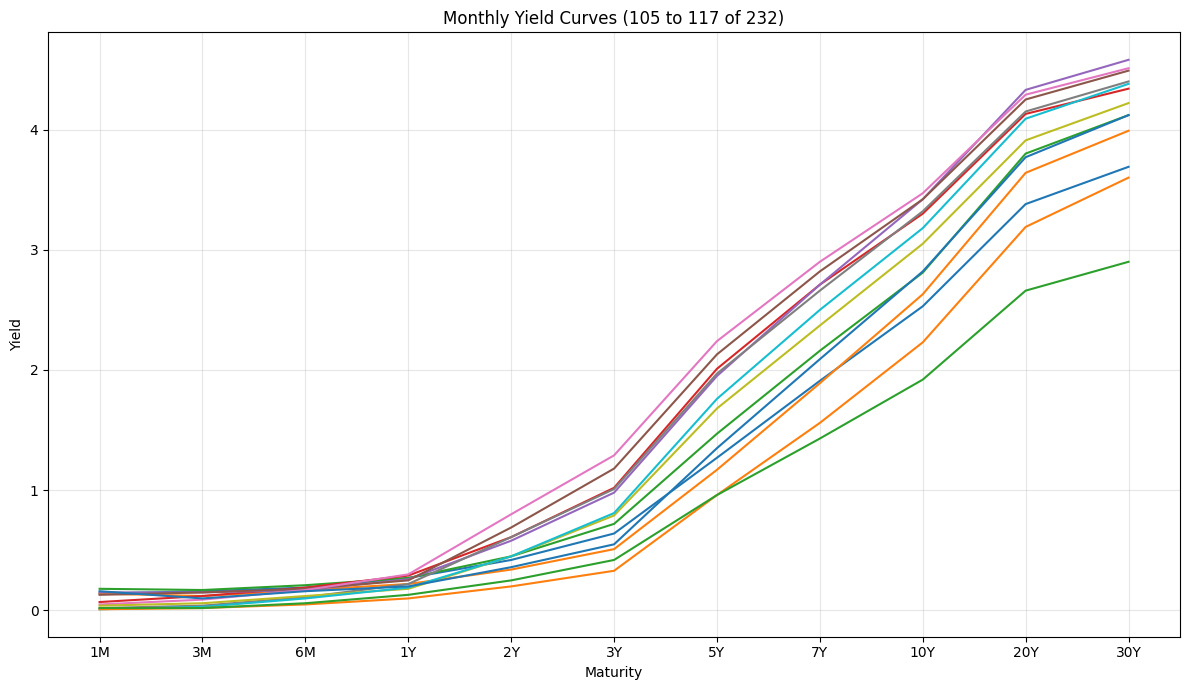

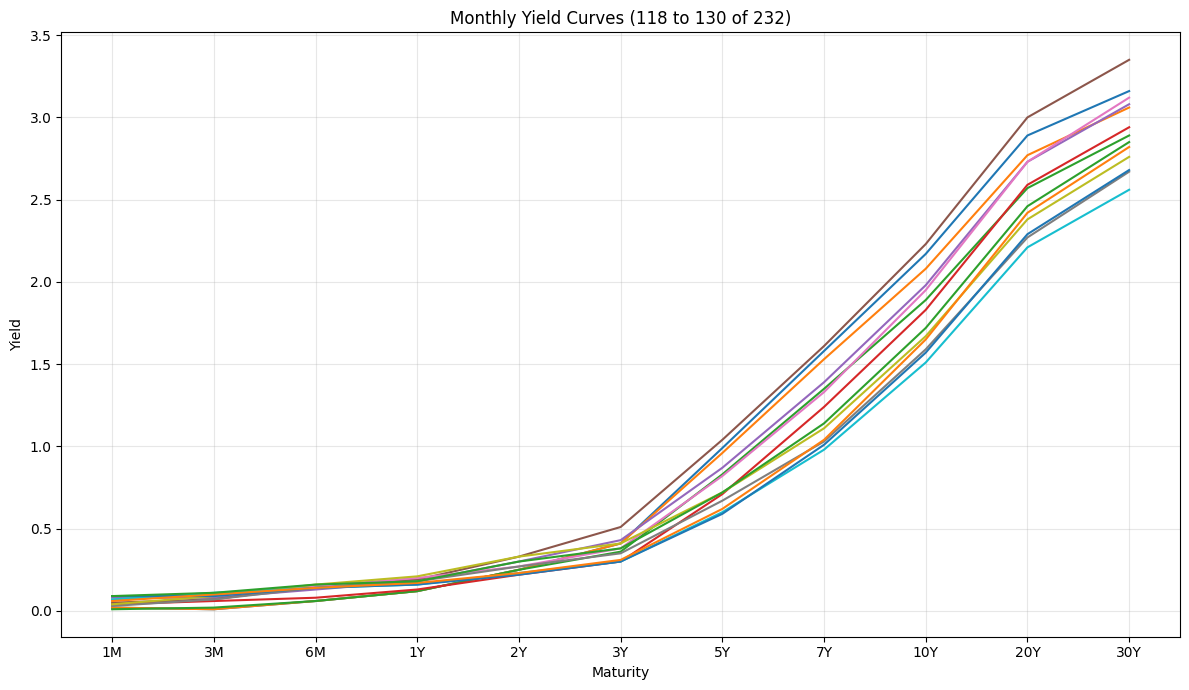

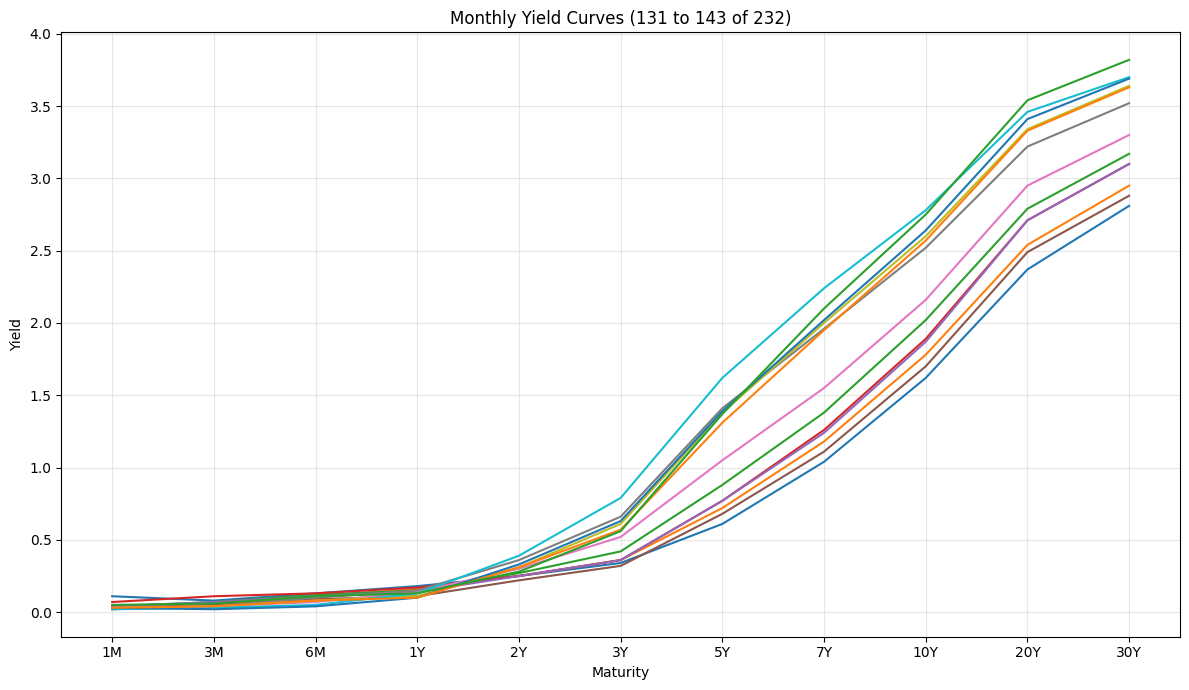

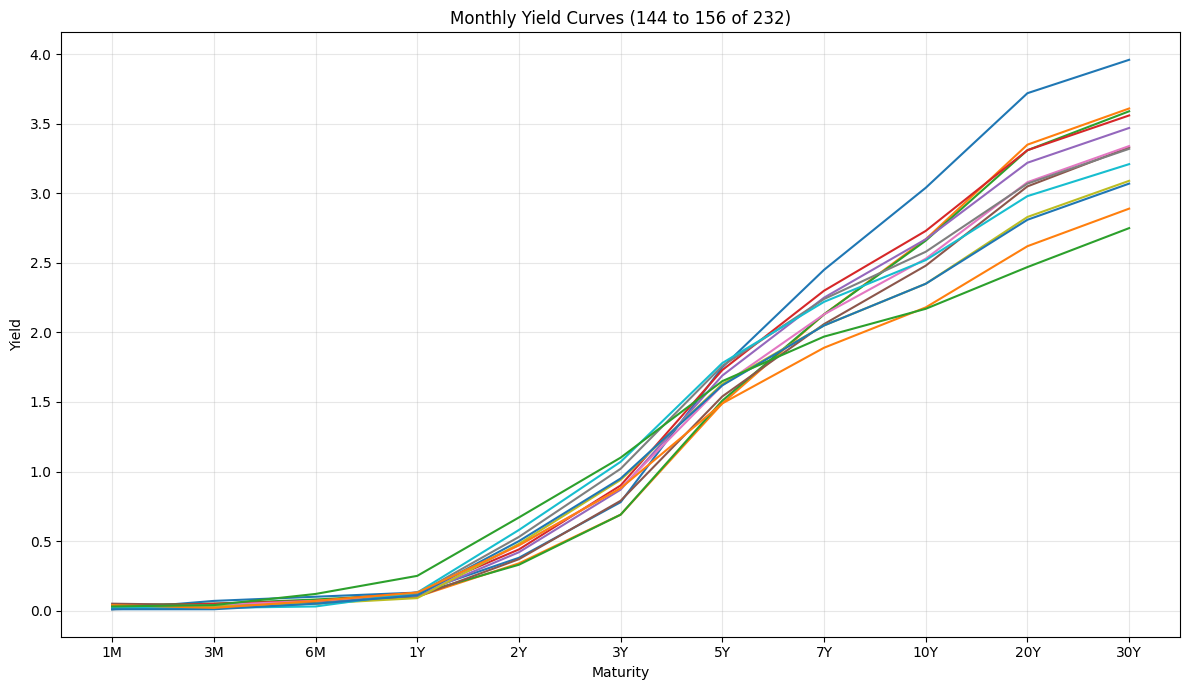

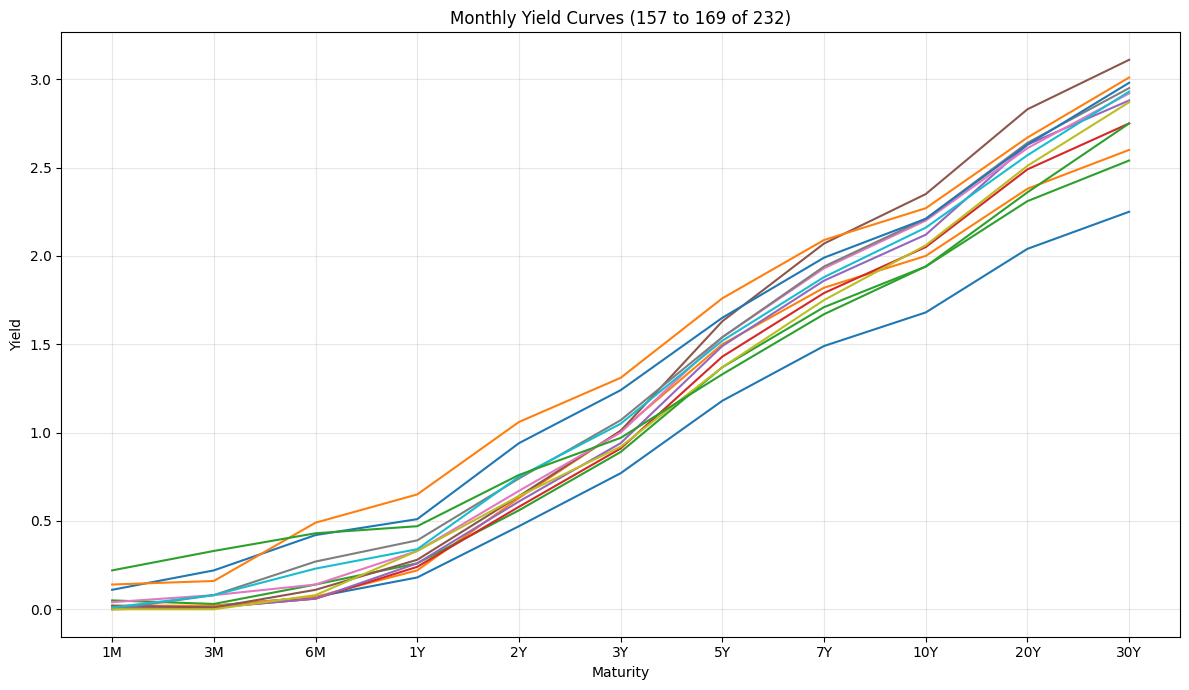

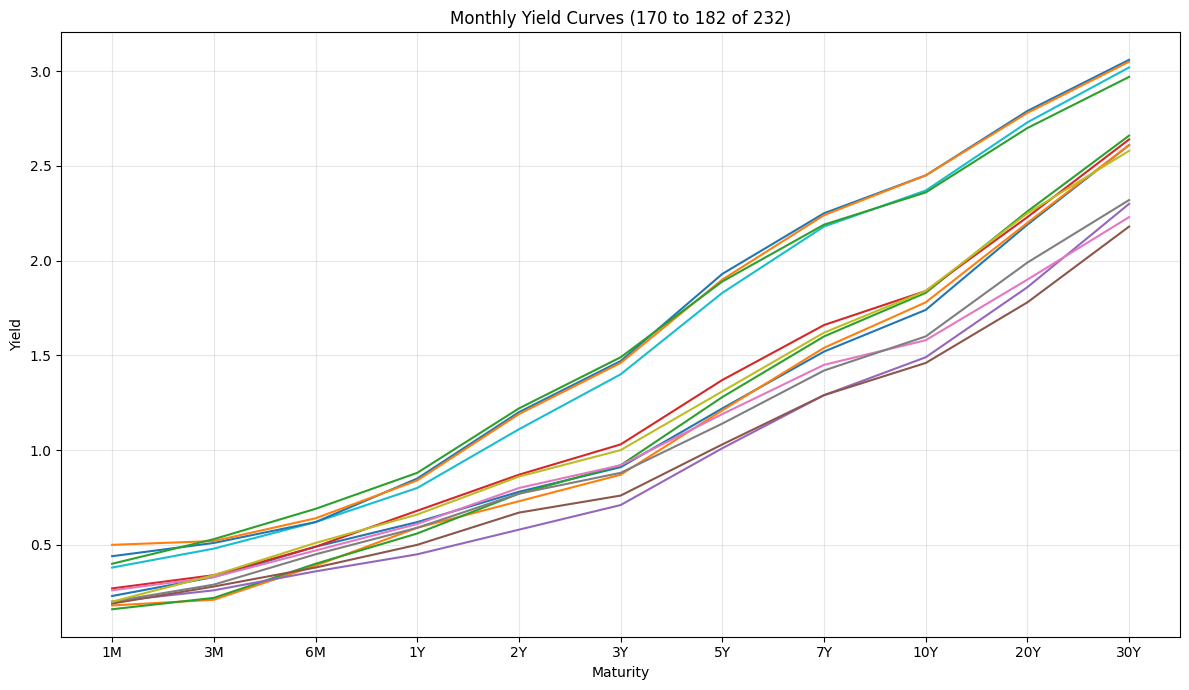

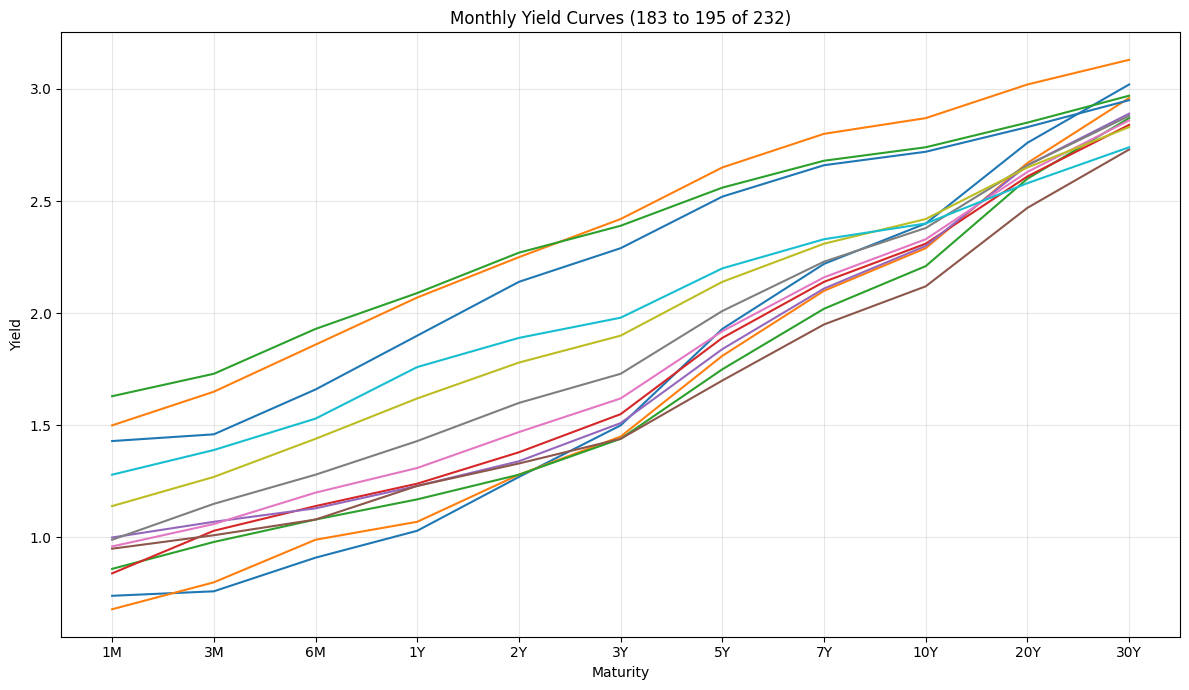

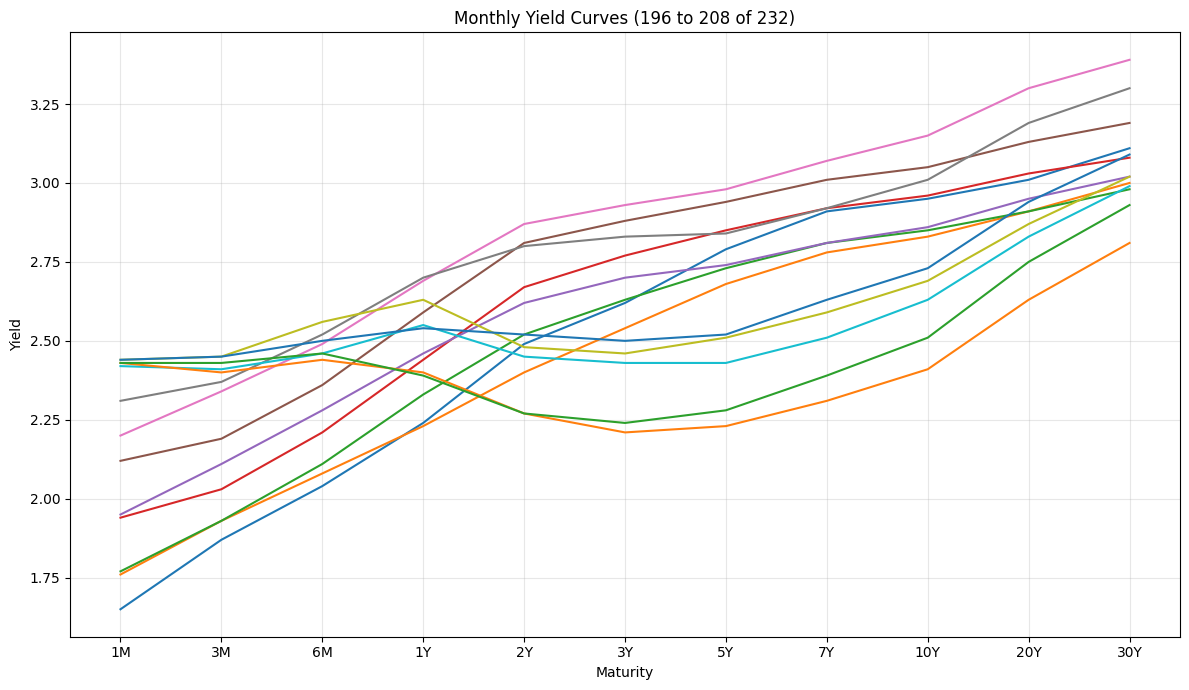

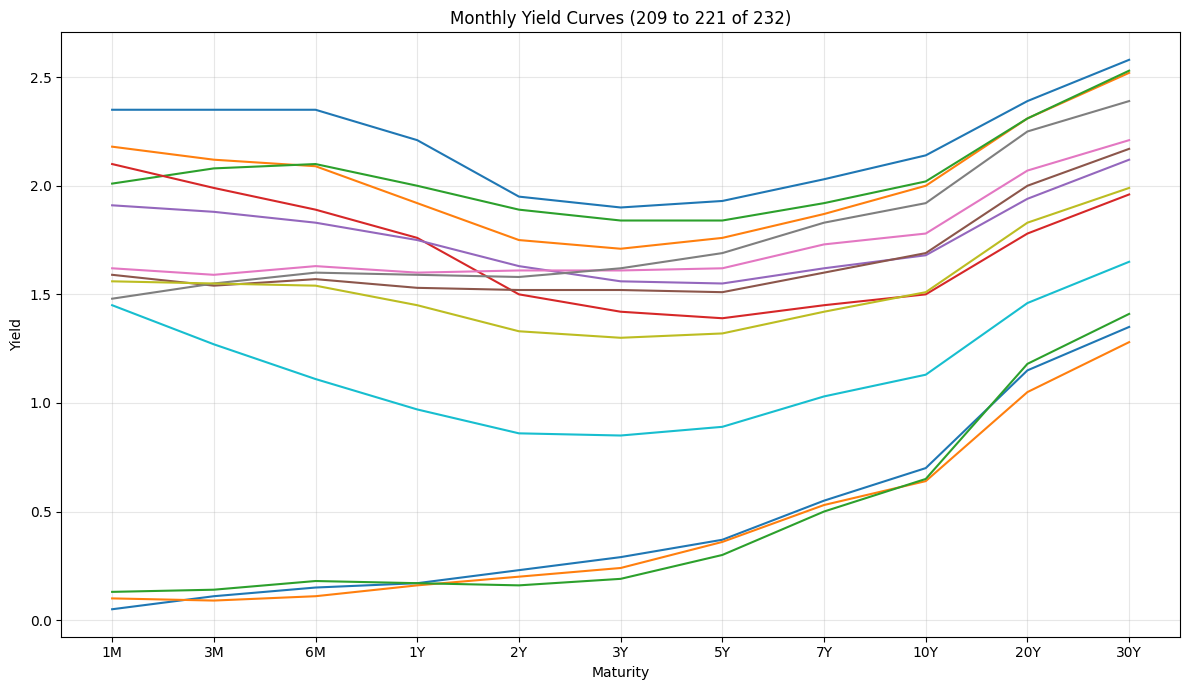

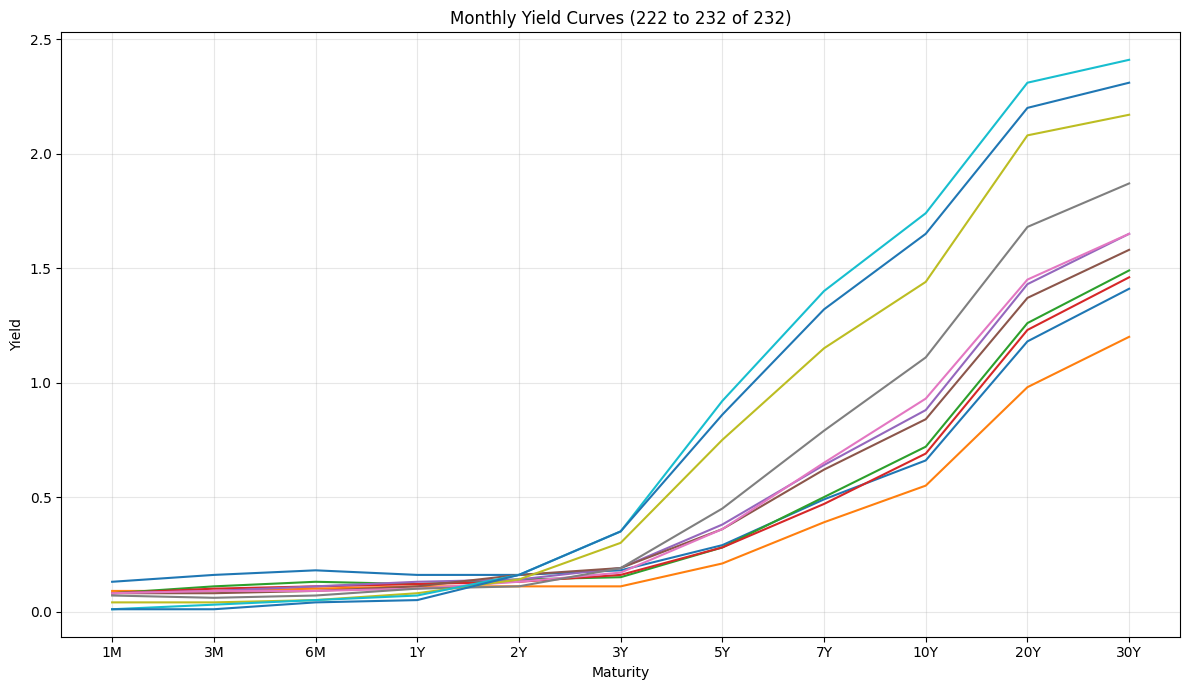

In [9]:
import math
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Settings you can change
# =========================
file_path = "raw_macro_yield_train.xls - raw_macro_yield_train (1).xls.csv"

# How many monthly yield curves to show per figure
curves_per_figure = 13

# Choose which monthly observation to use:
# "last" = last available trading day of each month
# "first" = first available trading day of each month
monthly_pick = "last"


# =========================
# Load data
# =========================
df = pd.read_csv(file_path)
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

# Yield columns in maturity order
yield_cols = [
    "Yield_1M", "Yield_3M", "Yield_6M", "Yield_1Y", "Yield_2Y",
    "Yield_3Y", "Yield_5Y", "Yield_7Y", "Yield_10Y", "Yield_20Y", "Yield_30Y"
]

# Nice labels for the x-axis
maturity_labels = ["1M", "3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]


# =========================
# Keep one curve per month
# =========================
df["YearMonth"] = df["DATE"].dt.to_period("M")

if monthly_pick == "last":
    monthly_curves = df.groupby("YearMonth", as_index=False).tail(1).copy()
elif monthly_pick == "first":
    monthly_curves = df.groupby("YearMonth", as_index=False).head(1).copy()
else:
    raise ValueError("monthly_pick must be 'last' or 'first'")

monthly_curves = monthly_curves.sort_values("DATE").reset_index(drop=True)


# =========================
# Plot in batches
# =========================
n_curves = len(monthly_curves)
n_figures = math.ceil(n_curves / curves_per_figure)

for fig_idx in range(n_figures):
    start = fig_idx * curves_per_figure
    end = min((fig_idx + 1) * curves_per_figure, n_curves)
    chunk = monthly_curves.iloc[start:end]

    plt.figure(figsize=(12, 7))

    for _, row in chunk.iterrows():
        y = row[yield_cols].values
        label = row["DATE"].strftime("%Y-%m")
        plt.plot(maturity_labels, y, label=label)

    plt.title(f"Monthly Yield Curves ({start + 1} to {end} of {n_curves})")
    plt.xlabel("Maturity")
    plt.ylabel("Yield")
    plt.grid(True, alpha=0.3)
    #plt.legend(title="Month", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()